In [1]:
import warnings
import copy

warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt
import anndata as ad
import pertpy as pt
import scanpy as sc
import numpy as np
import pandas as pd
import math
import seaborn as sns

sccoda_model = pt.tl.Sccoda()

In [5]:
adata_age_nk= sc.read_h5ad("/scratch/user/s4575250/BIOX7018_thesis/write/03_batch_expression/PICA_Batch001-Batch007/PICA_Batch001-Batch007_nk_combined_annot_with_age_scvi.h5ad")

In [6]:
adata_age_nk

AnnData object with n_obs × n_vars = 1504 × 2889
    obs: 'status', 'assignment', 'pica_id', 'pool_id', 'sequencing_batch', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'status_manual', 'cell_type', 'broad_cell_type', 'pica_broad_cell_type', 'pica_cell_type', 'pica_cell_type_01_myeloid', 'pica_cell_type_02_b', 'pica_cell_type_03_nk_t', 'pica_cell_type_complete', 'pica_broad_cell_type_complete', 'pica_broad_cell_type_complete_01_gdT_corrected', 'pica_cell_type_complete_01_gdT_corrected', 'status_manual_01_pica', 'Record ID', 'Event Name', 'Was baseline blood sample collected?', 'IFC ID', "Child's sex", 'Age in years at the time of collectio

In [7]:
adata_age_nk.obs["Age_group"].value_counts().sort_index()

Age_group
0–3       78
4–6      334
7–10     480
11–14    401
15–18    211
Name: count, dtype: int64

In [8]:
adata_age_nk.obs['cell_type'].unique()
adata_age_nk.obs['cell_type'].value_counts()

cell_type
NK-like gamma-delta T cell       1292
NK-like gdT cell                  106
NKT                                35
Cytotoxic NK cell                  24
Cytokine-producing NK cell         19
Innate-like T cell                 12
ILC1                               11
Cytotoxic natural killer cell       2
ILC2                                2
ILC1/ILC2                           1
Name: count, dtype: int64

In [9]:
adata_age_nk.obs["Age_group"] = pd.Categorical(
        adata_age_nk.obs["Age_group"],
        categories=["0–3", "4–6", "7–10", "11–14", "15–18"],
        ordered=True,
    )

In [10]:
adata_age_nk.obs["Age_group"].value_counts().sort_index()

Age_group
0–3       78
4–6      334
7–10     480
11–14    401
15–18    211
Name: count, dtype: int64

In [11]:
adata_age_nk.obs["Child's sex"] = adata_age_nk.obs["Child's sex"].astype("category")

In [12]:
# build sccoda input from cell-level data
def make_sccoda_from_lineage(
    adata,
    cell_type_col="cell_type",   
    sample_col="pica_id",       
    covariates=("Age_group","Child's sex"), 
):
    sccoda_data = sccoda_model.load(
        adata,
        type="cell_level",
        generate_sample_level=True,
        cell_type_identifier=cell_type_col,
        sample_identifier=sample_col,
        covariate_obs=list(covariates),
    )
    return sccoda_data

In [13]:
sccoda_nk = make_sccoda_from_lineage(adata_age_nk, cell_type_col="cell_type")

In [14]:
sccoda_nk

MuData object with n_obs × n_vars = 1574 × 2899
  2 modalities
    rna:	1504 x 2889
      obs:	'status', 'assignment', 'pica_id', 'pool_id', 'sequencing_batch', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'status_manual', 'cell_type', 'broad_cell_type', 'pica_broad_cell_type', 'pica_cell_type', 'pica_cell_type_01_myeloid', 'pica_cell_type_02_b', 'pica_cell_type_03_nk_t', 'pica_cell_type_complete', 'pica_broad_cell_type_complete', 'pica_broad_cell_type_complete_01_gdT_corrected', 'pica_cell_type_complete_01_gdT_corrected', 'status_manual_01_pica', 'Record ID', 'Event Name', 'Was baseline blood sample collected?', 'IFC ID', "Child's sex", 'Age in years at the time of collection', 'Age in months at the time of collection', '1) Does your child have any significant health issue or condition?', 'Date and time of blood collection', '4) Does your child have any allergies diagnosed by a medical practitioner?', '5) Has your child shown any allergic symptoms within the last 2 months?', '7) Is your child on any medication? (including immune-modulating medications like steroids in the last two weeks)?', '6) Does your child or your family have any history of immune disease? (such as immunodeficiencies and autoimmune disorders like lupus, type 1 diabetes, vasculitis, etc.) (choice=No)', '6) Does your child or your family have any history of immune disease? (such as immunodeficiencies and autoimmune disorders like lupus, type 1 diabetes, vasculitis, etc.) (choice=Child)', '6) Does your child or your family have any history of immune disease? (such as immunodeficiencies and autoimmune disorders like lupus, type 1 diabetes, vasculitis, etc.) (choice=Family member(s))', 'My family member has a history of (specify family member)', 'My child has a history of:  (Specify diagnosis date)', '8) Has your child ever been breastfed?', "9) What is your child's ethnicity? (choice=White Australian)", "9) What is your child's ethnicity? (choice=Australian Aboriginal)", "9) What is your child's ethnicity? (choice=Australian South Sea Islander)", "9) What is your child's ethnicity? (choice=Torres Strait Islander)", "9) What is your child's ethnicity? (choice=Māori)", "9) What is your child's ethnicity? (choice=New Zealander)", "9) What is your child's ethnicity? (choice=Pacific Islander)", "9) What is your child's ethnicity? (choice=North-West European)", "9) What is your child's ethnicity? (choice=Southern and Eastern European)", "9) What is your child's ethnicity? (choice=North African and Middle Eastern)", "9) What is your child's ethnicity? (choice=South-East Asian)", "9) What is your child's ethnicity? (choice=North-East Asian)", "9) What is your child's ethnicity? (choice=Southern and Central Asian)", "9) What is your child's ethnicity? (choice=Latin American and Caribbean)", "9) What is your child's ethnicity? (choice=Sub-Saharan African)", "9) What is your child's ethnicity? (choice=Decline to answer)", "9) What is your child's ethnicity? (choice=Other, please specify:)", 'Specify ethnicity', 'Age in years int', 'Age_group', '_scvi_batch', '_scvi_labels', 'scCODA_sample_id'
      var:	'gene_ids', 'feature_types', 'genome', 'mt', 'ribo', 'hb', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
      uns:	'Age_group_colors', "Child's sex_colors", '_scvi_manager_uuid', '_scvi_uuid', 'cell_type_colors', 'hvg', 'log1p', 'neighbors', 'pca', 'pica_broad_cell_type_complete_01_gdT_corrected_colors', 'sequencing_batch_colors', 'umap'
      obsm:	'X_pca', 'X_scVI', 'X_umap'
      varm:	'PCs'
      layers:	'counts'
      obsp:	'connectivities', 'distances'
    coda:	70 x 10
      obs:	'pica_

## Age only model

In [17]:
counts = pd.DataFrame(
    sccoda_nk["coda"].X,
    index=sccoda_nk["coda"].obs_names,
    columns=sccoda_nk["coda"].var_names
)

# how many samples each cell type appears in (non-zero)
present_n = (counts > 0).sum(axis=0).sort_values(ascending=False)
present_n.head(10)

cell_type
NK-like gamma-delta T cell       22
Cytotoxic NK cell                20
NK-like gdT cell                 13
NKT                              11
Cytokine-producing NK cell       10
Innate-like T cell                9
ILC1                              4
Cytotoxic natural killer cell     2
ILC2                              2
ILC1/ILC2                         1
dtype: int64

In [18]:
# prepare sccoda model
def prepare_sccoda_age(sccoda_data, modality_key="coda"):
    # formula in patsy/R style: here only Age_group, but you can add + sex etc
    formula = "Age_group"

    sccoda_data = sccoda_model.prepare(
        sccoda_data,
        modality_key=modality_key,
        formula=formula,
        reference_cell_type="NK-like gamma-delta T cell",  # or e.g. "CD4_naive"
    )
    return sccoda_data

In [19]:
sccoda_nk = prepare_sccoda_age(sccoda_nk)

• Zero counts encountered in data! Added a pseudocount of 0.5.


In [20]:
# run sccoda
def run_sccoda(sccoda_data, modality_key="coda", rng_key=0):
    sccoda_model.run_nuts(
        sccoda_data,
        modality_key=modality_key,
        num_warmup=2000,
        num_samples=5000,
        rng_key=rng_key,
    )
    return sccoda_data

In [21]:
sccoda_nk = run_sccoda(sccoda_nk, rng_key=1)

sample: 100%|██████████| 7000/7000 [01:36<00:00, 72.42it/s, 127 steps of size 4.57e-02. acc. prob=0.71]


In [22]:
sccoda_model.summary(sccoda_nk, modality_key="coda", extended=True)

                                          Compositional Analysis summary                                           
┌───────────────────────────────────────┬─────────────────────────────────────────────────────────────────────────┐
│ Name                                  │ Value                                                                   │
├───────────────────────────────────────┼─────────────────────────────────────────────────────────────────────────┤
│ Data                                  │ Data: 70 samples, 10 cell types                                         │
│ Reference cell type                   │ NK-like gamma-delta T cell                                              │
│ Formula                               │ Age_group                                                               │
│ Reference index                       │ 7                                                                       │
│ Spike-and-slab threshold              │ 1.000                                                                   │
│ Spike-and-slab threshold              │ 1.000                                                                   │
│ MCMC Sampling                         │ Sampled 5000 chain states (2000 burnin samples)                         │
│ Acceptance rate                       │ 71.4%                                                                   │
└───────────────────────────────────────┴─────────────────────────────────────────────────────────────────────────┘

┌─────────────────────────────────────────────────────────────────────────────────────────────────────────────────┐
│ Intercepts                                                                                                      │
├─────────────────────────────────────────────────────────────────────────────────────────────────────────────────┤
│                                Final Parameter  HDI 3%  HDI 97%   SD   Expected Sample                          │
│ cell_type                                                                                                       │
│ Cytokine-producing NK cell         -0.374       -0.663  -0.086  0.155      1.931                                │
│ Cytotoxic NK cell                  -0.337       -0.619  -0.040  0.154      2.004                                │
│ Cytotoxic natural killer cell      -0.469       -0.759  -0.178  0.155      1.756                                │
│ ILC1                               -0.415       -0.710  -0.130  0.155      1.854                                │
│ ILC1/ILC2                          -0.480       -0.788  -0.197  0.158      1.737                                │
│ ILC2                               -0.470       -0.773  -0.186  0.155      1.754                                │
│ Innate-like T cell                 -0.405       -0.691  -0.120  0.153      1.872                                │
│ NK-like gamma-delta T cell          1.103        0.796   1.428  0.169      8.458                                │
│ NK-like gdT cell                   -0.143       -0.440   0.181  0.165      2.433                                │
│ NKT                                -0.331       -0.610  -0.017  0.157      2.016                                │
└─────────────────────────────────────────────────────────────────────────────────────────────────────────────────┘

┌─────────────────────────────────────────────────────────────────────────────────────────────────────────────────┐
│ Effects                                                                                                         │
├─────────────────────────────────────────────────────────────────────────────────────────────────────────────────┤
│                                                 Final Parameter  Expected Sample  log2-fold change              │
│ Covariate        Cell Type                                                                                      │
│ Age_groupT.4–6   Cytokine-producing NK cell         0.000            1.931             0.000                    │
│                  Cytotoxic NK cell                  0.000            2.004             0.000                    │
│                  Cytotoxic natural killer cell      0.000            1.756             0.000                    │
│                  ILC1                               0.000            1.854             0.000                    │
│                  ILC1/ILC2                          0.000            1.737             0.000                    │
│                  ILC2                               0.000            1.754             0.000                    │
│                  Innate-like T cell                 0.000            1.872             0.000                    │
│                  NK-like gamma-delta T cell         0.000            8.458             0.000                    │
│                  NK-like gdT cell                   0.000            2.433             0.000                    │
│                  NKT                                0.000            2.016             0.000                    │
│ Age_groupT.7–10  Cytokine-producing NK cell         0.000            1.931             0.000                    │
│                  Cytotoxic NK cell                  0.000            2.004             0.000                    │
│                  Cytotoxic natural killer cell      0.000            1.756             0.000                    │
│                  ILC1                               0.000            1.854             0.000                    │
│                  ILC1/ILC2                          0.000            1.737             0.000                    │
│                  ILC2                               0.000            1.754             0.000                    │
│                  Innate-like T cell                 0.000            1.872             0.000                    │
│                  NK-like gamma-delta T cell         0.000            8.458             0.000                    │
│                  NK-like gdT cell                   0.000            2.433             0.000                    │
│                  NKT                                0.000            2.016             0.000                    │
│ Age_groupT.11–14 Cytokine-producing NK cell         0.000            1.931             0.000                    │
│                  Cytotoxic NK cell                  0.000            2.004             0.000                    │
│                  Cytotoxic natural killer cell      0.000            1.756             0.000                    │
│                  ILC1                               0.000            1.854             0.000                    │
│                  ILC1/ILC2                          0.000            1.737             0.000                    │
│                  ILC2                               0.000            1.754             0.000                    │
│                  Innate-like T cell                 0.000            1.872             0.000                    │
│                  NK-like gamma-delta T cell         0.000            8.458             0.000                    │
│                  NK-like gdT cell                   0.000            2.433             0.000                    │
│                  NKT                                0.

┌─────────────────────────────────────────────────────────────────────────────────────────────────────────────────┐
│ Effects Extended                                                                                                │
├─────────────────────────────────────────────────────────────────────────────────────────────────────────────────┤
│                                                 HDI 3%  HDI 97%   SD   Inclusion probability                    │
│ Covariate        Cell Type                                                                                      │
│ Age_groupT.4–6   Cytokine-producing NK cell     -0.451  0.266   0.133         0.490                             │
│                  Cytotoxic NK cell              -0.452  0.259   0.137         0.500                             │
│                  Cytotoxic natural killer cell  -0.424  0.273   0.125         0.473                             │
│                  ILC1                           -0.487  0.241   0.136         0.472                             │
│                  ILC1/ILC2                      -0.384  0.308   0.121         0.461                             │
│                  ILC2                           -0.400  0.280   0.123         0.490                             │
│                  Innate-like T cell             -0.353  0.284   0.114         0.486                             │
│                  NK-like gamma-delta T cell      0.000  0.000   0.000         0.000                             │
│                  NK-like gdT cell               -0.221  0.493   0.137         0.494                             │
│                  NKT                            -0.472  0.254   0.143         0.492                             │
│ Age_groupT.7–10  Cytokine-producing NK cell     -0.386  0.329   0.124         0.467                             │
│                  Cytotoxic NK cell              -0.379  0.285   0.119         0.477                             │
│                  Cytotoxic natural killer cell  -0.471  0.253   0.133         0.492                             │
│                  ILC1                           -0.372  0.307   0.122         0.482                             │
│                  ILC1/ILC2                      -0.386  0.292   0.123         0.467                             │
│                  ILC2                           -0.456  0.248   0.127         0.461                             │
│                  Innate-like T cell             -0.487  0.223   0.137         0.482                             │
│                  NK-like gamma-delta T cell      0.000  0.000   0.000         0.000                             │
│                  NK-like gdT cell               -0.741  0.129   0.228         0.605                             │
│                  NKT                            -0.290  0.371   0.114         0.471                             │
│ Age_groupT.11–14 Cytokine-producing NK cell     -0.259  0.284   0.093         0.460                             │
│                  Cytotoxic NK cell              -0.225  0.316   0.101         0.479                             │
│                  Cytotoxic natural killer cell  -0.267  0.270   0.095         0.483                             │
│                  ILC1                           -0.330  0.224   0.092         0.477                             │
│                  ILC1/ILC2                      -0.264  0.307   0.102         0.493                             │
│                  ILC2                           -0.237  0.317   0.098         0.474                             │
│                  Innate-like T cell             -0.235  0.303   0.099         0.483                             │
│                  NK-like gamma-delta T cell      0.000  0.000   0.000         0.000                             │
│                  NK-like gdT cell               -0.247  0.319   0.102         0.496                             │
│                  NKT                            -0.238

In [23]:
# set desired FDR globally
sccoda_model.set_fdr(sccoda_nk, est_fdr=0.1, modality_key="coda")

In [24]:
# check threshold
sccoda_nk["coda"].uns["scCODA_params"]["threshold_prob"]

1.0

In [25]:
effects_nk = sccoda_model.get_effect_df(sccoda_nk, modality_key="coda")

effects_nk["Inclusion probability"].max()
effects_nk["Inclusion probability"].describe()

count    40.000000
mean      0.435650
std       0.148682
min       0.000000
25%       0.470650
50%       0.479400
75%       0.490100
max       0.604600
Name: Inclusion probability, dtype: float64

In [26]:

# effects dataframe
effects_nk = sccoda_model.get_effect_df(sccoda_nk, modality_key="coda")
effects_nk.head()

Final Parameter  HDI 3%  \
Covariate      Cell Type                                                
Age_groupT.4–6 Cytokine-producing NK cell                 0.0  -0.451   
               Cytotoxic NK cell                          0.0  -0.452   
               Cytotoxic natural killer cell              0.0  -0.424   
               ILC1                                       0.0  -0.487   
               ILC1/ILC2                                  0.0  -0.384   

                                              HDI 97%     SD  \
Covariate      Cell Type                                       
Age_groupT.4–6 Cytokine-producing NK cell       0.266  0.133   
               Cytotoxic NK cell                0.259  0.137   
               Cytotoxic natural killer cell    0.273  0.125   
               ILC1                             0.241  0.136   
               ILC1/ILC2                        0.308  0.121   

                                              Inclusion probability  \
Covariate      Cell Type                                              
Age_groupT.4–6 Cytokine-producing NK cell                    0.4904   
               Cytotoxic NK cell                             0.5000   
               Cytotoxic natural killer cell                 0.4728   
               ILC1                                          0.4724   
               ILC1/ILC2                                     0.4610   

                                              Expected Sample  \
Covariate      Cell Type                                        
Age_groupT.4–6 Cytokine-producing NK cell            1.931073   
               Cytotoxic NK cell                     2.003861   
               Cytotoxic natural killer cell         1.756066   
               ILC1                                  1.853500   
               ILC1/ILC2                             1.736855   

                                              log2-fold change  
Covariate      Cell Type                                        
Age_groupT.4–6 Cytokine-producing NK cell                  0.0  
               Cytotoxic NK cell                           0.0  
               Cytotoxic natural killer cell               0.0  
               ILC1                                        0.0  
               ILC1/ILC2                                   0.0

In [27]:
# counts per sample x celltype
counts = pd.DataFrame(
    sccoda_nk["coda"].X,
    index=sccoda_nk["coda"].obs_names,
    columns=sccoda_nk["coda"].var_names,
)

# convert to proportions
props = counts.div(counts.sum(axis=1), axis=0)

# metadata (sample-level)
meta = sccoda_nk["coda"].obs.copy()

# long format for plotting
df = (
    props.join(meta["Age_group"])
    .reset_index(names="sample")
    .melt(id_vars=["sample", "Age_group"], var_name="Cell Type", value_name="Proportion")
)

In [28]:
df["Cell Type"].unique()

array(['Cytokine-producing NK cell', 'Cytotoxic NK cell',
       'Cytotoxic natural killer cell', 'ILC1', 'ILC1/ILC2', 'ILC2',
       'Innate-like T cell', 'NK-like gamma-delta T cell',
       'NK-like gdT cell', 'NKT'], dtype=object)

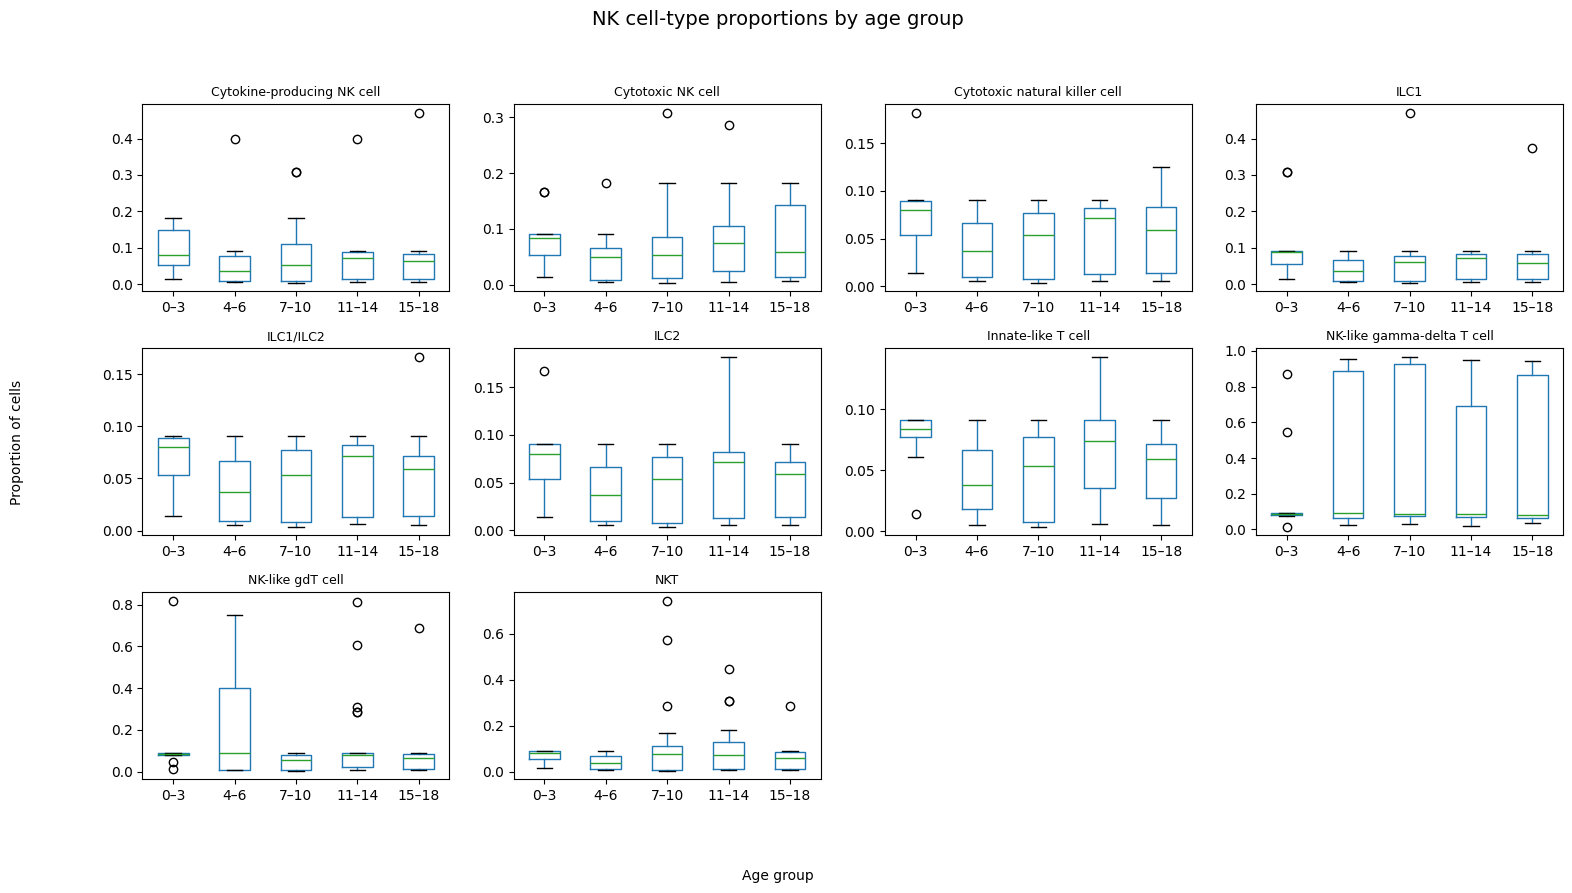

In [29]:
# boxplots of relative abundances per donor per age group
cell_types = sorted(df["Cell Type"].unique())

n_cols = 4
n_rows = math.ceil(len(cell_types) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(4*n_cols, 3*n_rows))
axes = axes.flatten()

for ax, cell in zip(axes, cell_types):
    sub = df[df["Cell Type"] == cell]
    sub.boxplot(
        column="Proportion",
        by="Age_group",
        grid=False,
        ax=ax
    )
    ax.set_title(cell, fontsize=9)
    ax.set_xlabel("")
    ax.set_ylabel("")

# remove empty panels
for ax in axes[len(cell_types):]:
    ax.axis("off")

plt.suptitle("NK cell-type proportions by age group", fontsize=14)
fig.supxlabel("Age group", fontsize=10)
fig.supylabel("Proportion of cells", fontsize=10)

plt.tight_layout(rect=[0.05, 0.05, 1, 0.95])
plt.show()

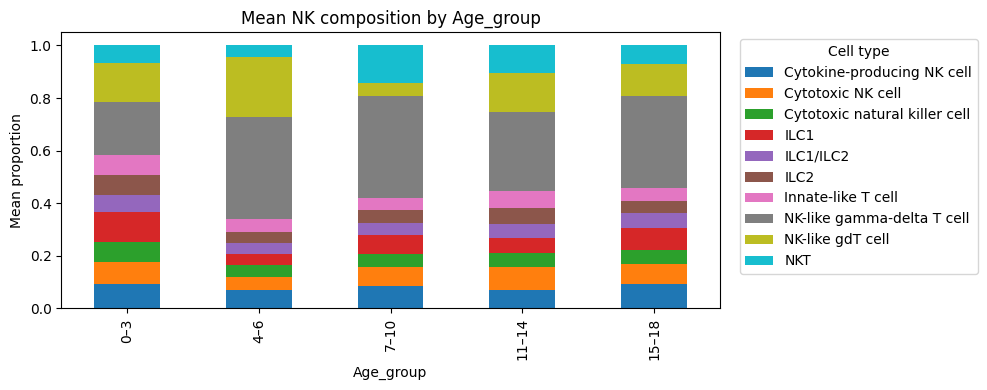

In [30]:
# barplot of composition by age group
props_age = props.join(meta["Age_group"]).groupby("Age_group").mean()

ax = props_age.plot(kind="bar", stacked=True, figsize=(10, 4))
ax.set_xlabel("Age_group")
ax.set_ylabel("Mean proportion")
ax.set_title("Mean NK composition by Age_group")
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", title="Cell type")
plt.tight_layout()
plt.show()

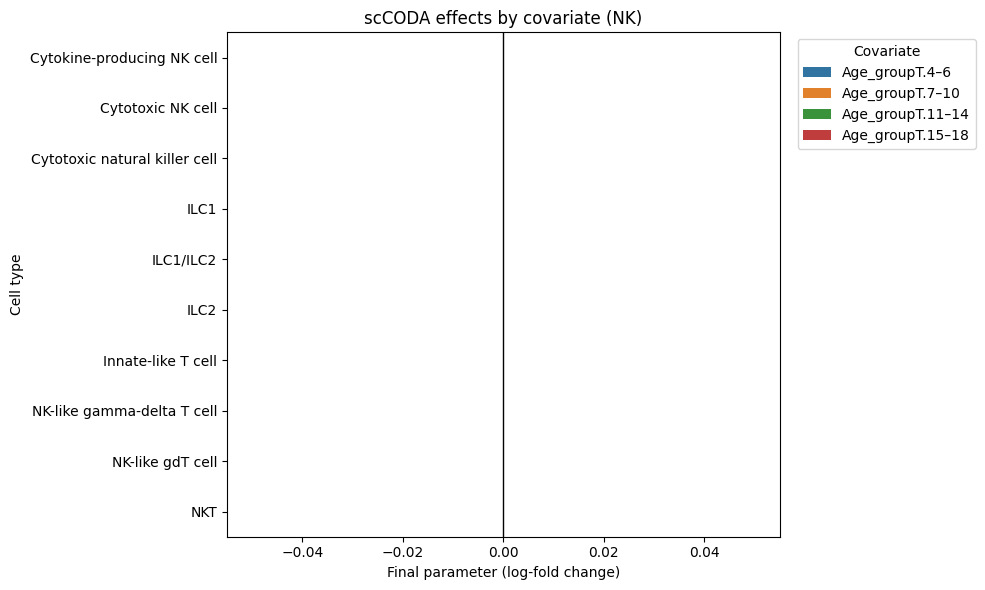

In [31]:
# effect barplot (may need to check your pertpy version)
plt.figure(figsize=(10, 6))

sns.barplot(
    data=effects_nk,
    y="Cell Type",
    x="Final Parameter",
    hue="Covariate",
    orient="h"
)

plt.axvline(0, color="black", linewidth=1)
plt.xlabel("Final parameter (log-fold change)")
plt.ylabel("Cell type")
plt.title("scCODA effects by covariate (NK)")
plt.legend(title="Covariate", bbox_to_anchor=(1.02, 1), loc="upper left")

plt.tight_layout()
plt.show()

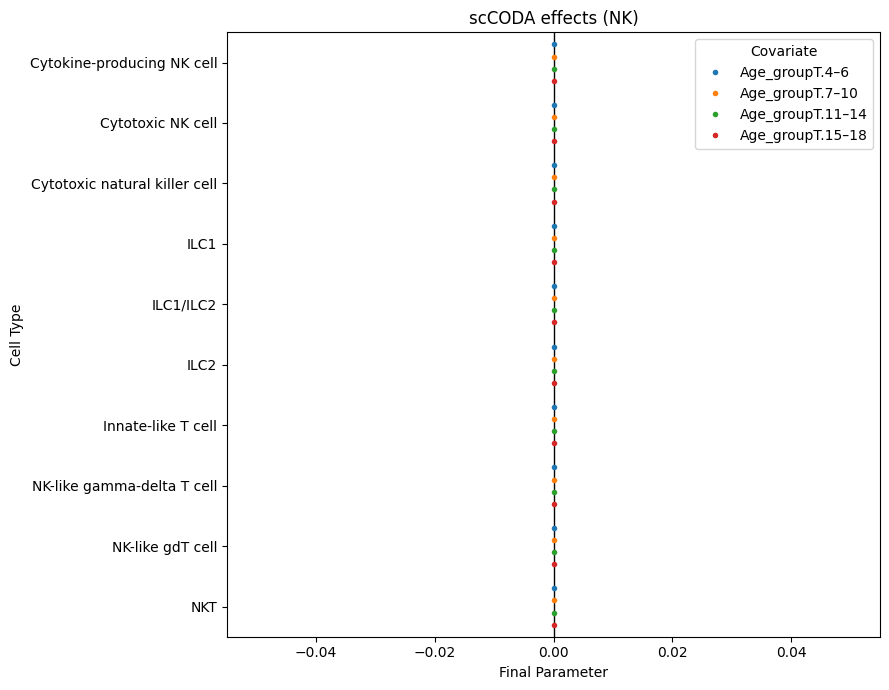

In [32]:
plt.figure(figsize=(9, 7))
sns.stripplot(
    data=effects_nk,
    y="Cell Type",
    x="Final Parameter",
    hue="Covariate",
    dodge=True,
    orient="h",
    size=4
)
plt.axvline(0, color="black", linewidth=1)
plt.title("scCODA effects (NK)")
plt.tight_layout()
plt.show()

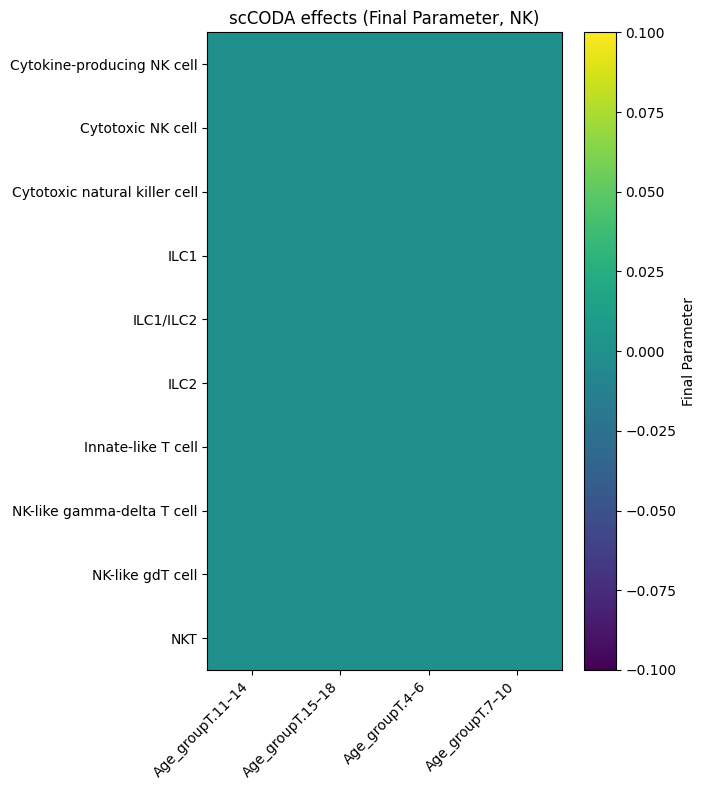

In [33]:
# inclusion pronbability heatmap
tmp = effects_nk.reset_index()
ip = tmp.pivot(index="Cell Type", columns="Covariate", values="Inclusion probability")

beta = effects_nk["Final Parameter"].unstack("Covariate")

plt.figure(figsize=(7, 8))
plt.imshow(beta.values, aspect="auto")
plt.yticks(range(beta.shape[0]), beta.index)
plt.xticks(range(beta.shape[1]), beta.columns, rotation=45, ha="right")
plt.colorbar(label="Final Parameter")
plt.title("scCODA effects (Final Parameter, NK)")
plt.tight_layout()
plt.show()

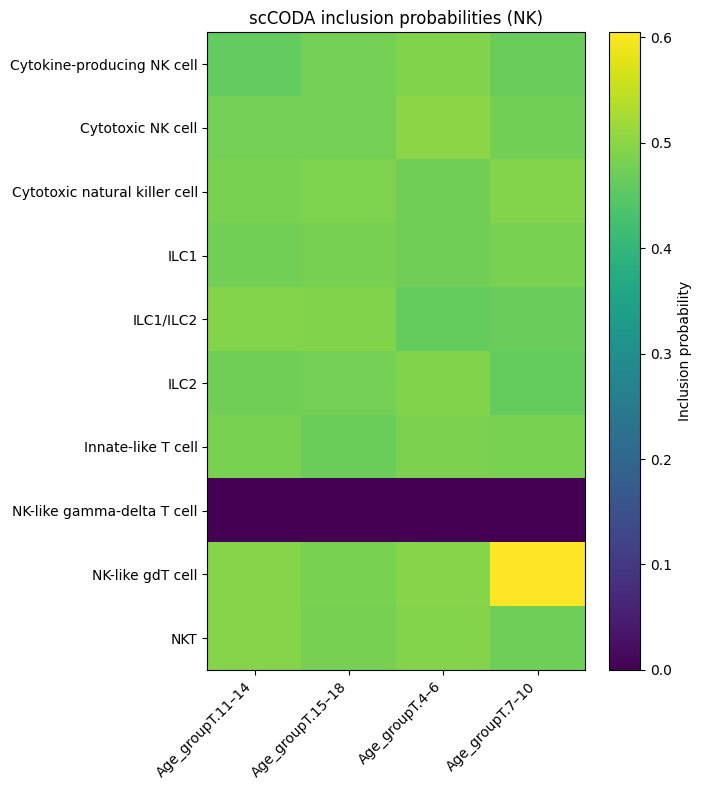

In [34]:
ip = effects_nk["Inclusion probability"].unstack("Covariate")
# now rows = Cell Type, cols = Covariate

plt.figure(figsize=(7, 8))
plt.imshow(ip.values, aspect="auto")
plt.yticks(range(ip.shape[0]), ip.index)
plt.xticks(range(ip.shape[1]), ip.columns, rotation=45, ha="right")
plt.colorbar(label="Inclusion probability")
plt.title("scCODA inclusion probabilities (NK)")
plt.tight_layout()
plt.show()

## Age + sex model

In [35]:
sccoda_nk["coda"].obs.columns


Index(['pica_id', 'Age_group', 'Child's sex'], dtype='object')

In [36]:
sccoda_nk["coda"].obs = sccoda_nk["coda"].obs.rename(columns={"Child's sex": "Child_sex"})


In [37]:
# prepare sccoda model
def prepare_sccoda_age_sex(sccoda_data, modality_key="coda"):
    formula = "Age_group + Child_sex"
    return sccoda_model.prepare(
        sccoda_data,
        modality_key=modality_key,
        formula=formula,
        reference_cell_type="NK-like gamma-delta T cell",
    )
    return sccoda_data

In [45]:
sccoda_nk_age_sex = sccoda_nk.copy()

In [46]:
## run sccoda
sccoda_nk_age_sex = prepare_sccoda_age_sex(sccoda_nk)
sccoda_nk_age_sex = run_sccoda(sccoda_nk_age_sex, rng_key=1)

  0%|          | 0/7000 [00:00<?, ?it/s]

sample: 100%|██████████| 7000/7000 [01:57<00:00, 59.56it/s, 127 steps of size 2.92e-02. acc. prob=0.85]


In [49]:
sccoda_model.summary(sccoda_nk_age_sex, modality_key="coda", extended=True)
effects_nk_age_sex = sccoda_model.get_effect_df(sccoda_nk_age_sex, modality_key="coda")
effects_nk_age_sex.head()

UnboundLocalError: cannot access local variable 'sample_adata' where it is not associated with a value

In [48]:
# counts per sample x celltype
counts = pd.DataFrame(
    sccoda_nk_age_sex["coda"].X,
    index=sccoda_nk_age_sex["coda"].obs_names,
    columns=sccoda_nk_age_sex["coda"].var_names,
)

# convert to proportions per sample (row)
props = counts.div(counts.sum(axis=1), axis=0)

# metadata (sample-level)
meta = sccoda_nk_age_sex["coda"].obs.copy()

df_age_sex = (
    props
    .join(meta[["Age_group", "Child_sex"]])   
    .reset_index(names="sample")
    .melt(
        id_vars=["sample", "Age_group", "Child_sex"],  
        var_name="Cell Type",
        value_name="Proportion",
    )
)

KeyError: 'coda'

In [ ]:
cell_types = sorted(df_age_sex["Cell Type"].unique())

n_cols = 4
n_rows = math.ceil(len(cell_types) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(4*n_cols, 3*n_rows))
axes = axes.flatten()

for ax, cell in zip(axes, cell_types):
    sub = df_age_sex[df_age_sex["Cell Type"] == cell]

    # grouped boxplot: Age_group on x, split by Sex
    # pandas boxplot supports grouping via `by=[...]`
    sub.boxplot(
        column="Proportion",
        by=["Age_group", "Child_sex"],
        grid=False,
        ax=ax,
        rot=45,
    )

    ax.set_title(cell, fontsize=9)
    ax.set_xlabel("")
    ax.set_ylabel("")

# remove empty panels
for ax in axes[len(cell_types):]:
    ax.axis("off")

# IMPORTANT: pandas boxplot adds an automatic suptitle; remove it
plt.suptitle("")

fig.suptitle("NK cell-type proportions by Age group and Sex", fontsize=14)
fig.supxlabel("Age group × Sex", fontsize=10)
fig.supylabel("Proportion of cells", fontsize=10)

plt.tight_layout(rect=[0.05, 0.05, 1, 0.95])
plt.show()


In [ ]:
SEX_COL = "Child_sex"  

# get ordered sex levels robustly
sex_series = df_age_sex[SEX_COL]
sex_levels = (
    list(sex_series.cat.categories) if pd.api.types.is_categorical_dtype(sex_series)
    else sorted(sex_series.dropna().unique())
)

for sex in sex_levels:
    df_sex = df_age_sex[df_age_sex[SEX_COL] == sex].copy()

    cell_types = sorted(df_sex["Cell Type"].unique())
    n_cols = 4
    n_rows = math.ceil(len(cell_types) / n_cols)

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 3 * n_rows), sharex=False, sharey=False)
    axes = axes.flatten()

    for ax, cell in zip(axes, cell_types):
        sub = df_sex[df_sex["Cell Type"] == cell]
        sub.boxplot(column="Proportion", by="Age_group", grid=False, ax=ax)

        ax.set_title(cell, fontsize=9)
        ax.set_xlabel("")
        ax.set_ylabel("")

    # turn off unused panels
    for ax in axes[len(cell_types):]:
        ax.axis("off")

    # remove pandas' automatic "by=..." title
    fig.suptitle(f"NK cell-type proportions by Age group ({SEX_COL} = {sex})", fontsize=14)
    fig.supxlabel("Age group", fontsize=10)
    fig.supylabel("Proportion of cells", fontsize=10)

    plt.tight_layout(rect=[0.05, 0.05, 1, 0.95])
    plt.show()

In [ ]:
# mean composition per Age_group × Sex
props_age_sex = (
    props
    .join(meta[["Age_group", SEX_COL]])
    .groupby(["Age_group", SEX_COL])
    .mean()
)

for sex in props_age_sex.index.get_level_values(SEX_COL).unique():
    df_plot = props_age_sex.xs(sex, level=SEX_COL)

    ax = df_plot.plot(
        kind="bar",
        stacked=True,
        figsize=(10, 4)
    )

    ax.set_xlabel("Age group")
    ax.set_ylabel("Mean proportion")
    ax.set_title(f"Mean NK composition by Age group ({SEX_COL} = {sex})")

    ax.legend(
        bbox_to_anchor=(1.02, 1),
        loc="upper left",
        title="Cell type"
    )

    plt.tight_layout()
    plt.show()

In [ ]:
# combine index for plotting
props_age_sex.index = props_age_sex.index.map(
    lambda x: f"{x[0]} | {x[1]}"
)

ax = props_age_sex.plot(
    kind="bar",
    stacked=True,
    figsize=(12, 4)
)

ax.set_xlabel("Age group | Sex")
ax.set_ylabel("Mean proportion")
ax.set_title("Mean NK composition by Age group and Sex")

ax.legend(
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    title="Cell type"
)

plt.tight_layout()
plt.show()

In [ ]:
effects = effects_nk_age_sex.reset_index().copy()

effects["Covariate_type"] = effects["Covariate"].apply(
    lambda x: "Age_group" if str(x).startswith("Age_group") else "Sex")

In [ ]:
g = sns.FacetGrid(
    effects,
    col="Covariate_type",
    sharey=True,
    height=7,
    aspect=0.9
)

g.map_dataframe(
    sns.stripplot,
    y="Cell Type",
    x="Final Parameter",
    hue="Covariate",
    dodge=True,
    orient="h",
    size=4
)

for ax in g.axes.flat:
    ax.axvline(0, color="black", linewidth=1)

g.add_legend(title="Covariate")
g.set_titles("{col_name} effects")
g.fig.suptitle("scCODA effects on NK composition (Age + Sex)", y=1.02)

plt.tight_layout()
plt.show()

In [ ]:
plt.figure(figsize=(10, 7))

sns.stripplot(
    data=effects_nk_age_sex,
    y="Cell Type",
    x="Final Parameter",
    hue="Covariate",
    dodge=True,
    orient="h",
    size=4
)

plt.axvline(0, color="black", linewidth=1)
plt.title("scCODA effects on NK composition (Age + Sex)")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

In [ ]:
effects = effects_nk_age_sex.copy()
print("index names:", effects.index.names)

In [ ]:
beta = effects["Final Parameter"].unstack(level=0)          # cols = covariate
ip   = effects["Inclusion probability"].unstack(level=0)    # cols = covariate

# now rows = Cell Type, cols = Covariate (flip if needed)
# If you prefer rows=Cell Type, cols=Covariate:
beta = beta.T if beta.index.name != "Cell Type" and beta.shape[0] < beta.shape[1] else beta
ip   = ip.T   if ip.index.name != "Cell Type" and ip.shape[0] < ip.shape[1] else ip

In [ ]:
# Final Parameter heatmap
plt.figure(figsize=(9, 8))
plt.imshow(beta.values, aspect="auto")
plt.yticks(range(beta.shape[0]), beta.index)
plt.xticks(range(beta.shape[1]), beta.columns, rotation=45, ha="right")
plt.colorbar(label="Final Parameter (log-fold change)")
plt.title("scCODA effects (Final Parameter) — Age + Sex")
plt.tight_layout()
plt.show()

# Inclusion probability heatmap
plt.figure(figsize=(9, 8))
plt.imshow(ip.values, aspect="auto")
plt.yticks(range(ip.shape[0]), ip.index)
plt.xticks(range(ip.shape[1]), ip.columns, rotation=45, ha="right")
plt.colorbar(label="Inclusion probability")
plt.title("scCODA inclusion probabilities — Age + Sex")
plt.tight_layout()
plt.show()